In [23]:
"""
3D ERT Forward Modeling with MODFLOW Integration
================================================

This example demonstrates the complete workflow for 3D ERT forward modeling
using PyHydroGeophysX, integrating hydrological model outputs.
"""

'\n3D ERT Forward Modeling with MODFLOW Integration\n================================================\n\nThis example demonstrates the complete workflow for 3D ERT forward modeling\nusing PyHydroGeophysX, integrating hydrological model outputs.\n'

# 3D ERT Forward Modeling Workflow with Topography

This example demonstrates 3D ERT forward modeling using PyHydroGeophysX,
integrating MODFLOW hydrological model outputs with realistic topography.

## Workflow Overview

1. **Tutorial**: Learn how to use `mesh_3d.py` module
2. Load MODFLOW water content and porosity data
3. Create 3D mesh with topography and electrode positions
4. Interpolate hydrological properties to 3D mesh
5. Convert water content to resistivity using petrophysical relationships
6. Perform 3D ERT forward modeling
7. Visualize results

---

## Tutorial: Using `mesh_3d.py` for 3D Mesh Creation

The `mesh_3d.py` module provides a `Mesh3DCreator` class with several methods
for creating different types of 3D meshes. Here's a quick reference:

### Key Classes and Functions

| Class/Function | Description |
|----------------|-------------|
| `Mesh3DCreator` | Main class for creating 3D meshes |
| `create_surface_electrode_array()` | Create regular surface electrode grid |
| `create_borehole_electrode_array()` | Create electrodes for borehole |
| `create_crosshole_electrode_array()` | Create multi-borehole electrode setup |
| `create_3d_mesh_with_topography()` | **Create mesh following topography** |
| `apply_topography_to_electrodes()` | Apply surface elevation to electrodes |
| `create_box_mesh()` | Create simple box mesh (flat surface) |
| `create_prism_mesh_from_2d()` | Extrude 2D mesh to 3D prisms |

### Quick Start Examples

```python
from PyHydroGeophysX.core.mesh_3d import Mesh3DCreator

# Initialize mesh creator
creator = Mesh3DCreator(
    mesh_directory='./meshes',
    elec_refinement=0.5,    # Mesh size near electrodes
    node_refinement=2.0,     # Mesh size at boundaries
    attractor_distance=5.0   # Distance for mesh refinement
)

# Example 1: Surface electrode array
electrodes = creator.create_surface_electrode_array(
    nx=10, ny=6,   # Grid size
    dx=5.0, dy=5.0, # Spacing
    x_offset=0, y_offset=0,
    z=0.0  # Surface elevation
)

# Example 2: Apply topography to electrodes
electrodes = creator.apply_topography_to_electrodes(
    electrodes,
    topography_func=lambda x, y: 100 + 0.1*x - 0.05*y  # Example
)

# Example 3: Create 3D mesh with topography
mesh = creator.create_3d_mesh_with_topography(
    electrode_positions=electrodes,
    topography_func=lambda x, y: 100 + 0.1*x,
    para_depth=20.0,
    use_prism_mesh=True
)
```

In [28]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import importlib

# PyGIMLi imports
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert

# Setup package path for development
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Import and reload PyHydroGeophysX modules (ensures latest code is used)
import PyHydroGeophysX.core.mesh_3d as mesh_3d_module
importlib.reload(mesh_3d_module)

from PyHydroGeophysX.core.mesh_3d import (
    Mesh3DCreator,
    create_3d_ert_data_container,
    interpolate_modflow_to_3d_mesh
)
from PyHydroGeophysX.petrophysics.resistivity_models import WS_Model

# Optional: PyVista for 3D visualization
try:
    import pyvista as pv
    from pygimli.viewer import pv as pgpv
    PYVISTA_AVAILABLE = True
    pv.set_plot_theme("document")
except ImportError:
    PYVISTA_AVAILABLE = False
    print("PyVista not available. 3D visualization will be limited.")

print(f"PyGIMLi version: {pg.__version__}")
print(f"Mesh3DCreator methods: {[m for m in dir(Mesh3DCreator) if not m.startswith('_')]}")

PyGIMLi version: 1.5.4
Mesh3DCreator methods: ['apply_topography_to_electrodes', 'convert_to_pygimli', 'create_3d_mesh_with_topography', 'create_borehole_electrode_array', 'create_box_mesh', 'create_crosshole_electrode_array', 'create_electrode_grid', 'create_prism_mesh_from_2d', 'create_surface_electrode_array', 'create_surface_mesh_with_topography', 'generate_gmsh_mesh', 'visualize_mesh', 'write_gmsh_geo_file']


In [29]:
# Create output directory
output_dir = "results/3d_ert_workflow"
os.makedirs(output_dir, exist_ok=True)

## Step 1: Define Domain Geometry and Create Electrodes on Topographic Surface

We'll create a 3D domain with a surface electrode array that follows realistic topography.
This is essential for accurate ERT modeling in areas with significant terrain variation.

In [30]:
# Define domain dimensions (in meters)
domain_length = 50.0  # x-direction
domain_width = 30.0   # y-direction  
domain_depth = 20.0   # z-direction (depth below surface)

# Create mesh creator with appropriate refinement settings
mesh_creator = Mesh3DCreator(
    mesh_directory=os.path.join(output_dir, 'meshes'),
    elec_refinement=0.5,      # Fine mesh near electrodes
    node_refinement=2.0,       # Coarser mesh at boundaries
    attractor_distance=5.0     # Distance for refinement transition
)

# Create surface electrode array (10x6 grid)
electrode_positions = mesh_creator.create_surface_electrode_array(
    nx=10, ny=6,
    dx=5.0, dy=5.0,
    x_offset=2.5,
    y_offset=2.5,
    z=0.0  # Will be updated with topography
)

print(f"Number of electrodes: {len(electrode_positions)}")
print(electrode_positions.head(10))

Number of electrodes: 60
    n     x    y    z
0   1   2.5  2.5  0.0
1   2   7.5  2.5  0.0
2   3  12.5  2.5  0.0
3   4  17.5  2.5  0.0
4   5  22.5  2.5  0.0
5   6  27.5  2.5  0.0
6   7  32.5  2.5  0.0
7   8  37.5  2.5  0.0
8   9  42.5  2.5  0.0
9  10  47.5  2.5  0.0


In [31]:
# Define topography function
# This example creates a sloping surface with some undulation
# Replace with your actual topography data or function

def topography_function(x, y):
    """
    Example topography function returning elevation for (x, y) coordinates.
    
    This creates a surface sloping from ~105m at (0,0) to ~95m at (50,30)
    with some undulation for realism.
    """
    # Base slope
    base_elevation = 100.0
    slope_x = -0.1  # m/m slope in x direction
    slope_y = -0.05  # m/m slope in y direction
    
    # Add some undulation for realism
    undulation = 0.5 * np.sin(x / 10.0) * np.cos(y / 8.0)
    
    elevation = base_elevation + slope_x * x + slope_y * y + undulation
    return elevation

# Apply topography to electrode positions using mesh_3d.py
electrode_positions = mesh_creator.apply_topography_to_electrodes(
    electrode_positions,
    topography_func=topography_function
)

print("Electrodes with topography applied:")
print(f"  Z range: {electrode_positions['z'].min():.2f} to {electrode_positions['z'].max():.2f} m")
print(electrode_positions.head(10))

Electrodes with topography applied:
  Z range: 94.35 to 99.74 m
    n     x    y          z
0   1   2.5  2.5  99.742711
1   2   7.5  2.5  99.449313
2   3  12.5  2.5  99.076512
3   4  17.5  2.5  98.593165
4   5  22.5  2.5  97.995195
5   6  27.5  2.5  97.306588
6   7  32.5  2.5  96.573522
7   8  37.5  2.5  95.853060
8   9  42.5  2.5  95.199178
9  10  47.5  2.5  94.649553


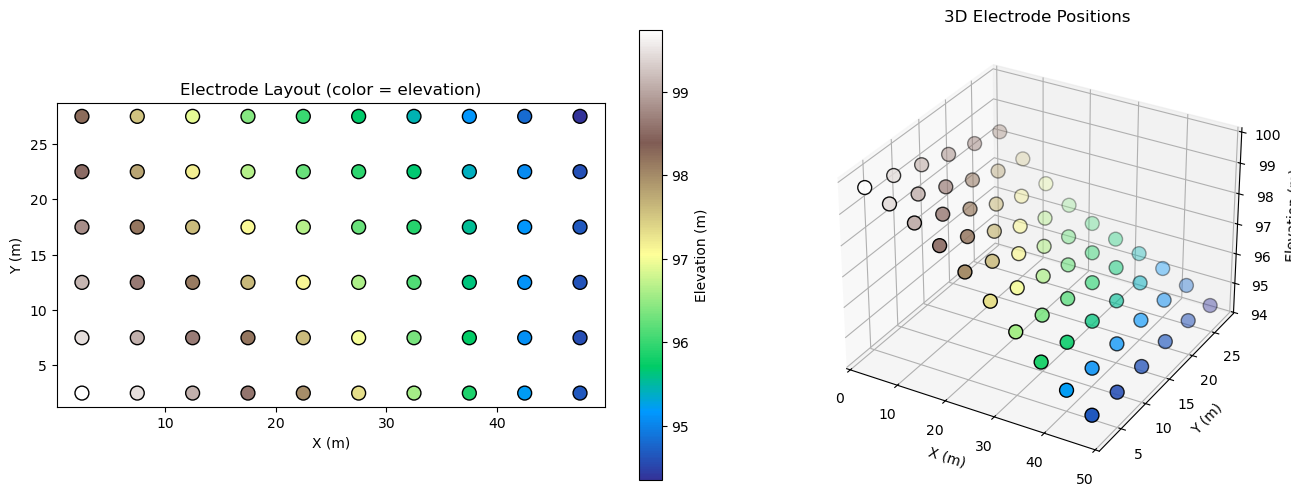

In [32]:
# Visualize electrode layout with topography
fig = plt.figure(figsize=(14, 5))

# 2D Layout
ax1 = fig.add_subplot(121)
scatter = ax1.scatter(
    electrode_positions['x'], 
    electrode_positions['y'],
    c=electrode_positions['z'],
    cmap='terrain',
    s=100,
    edgecolors='black'
)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_title('Electrode Layout (color = elevation)')
ax1.set_aspect('equal')
plt.colorbar(scatter, ax=ax1, label='Elevation (m)')

# 3D Layout
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(
    electrode_positions['x'], 
    electrode_positions['y'],
    electrode_positions['z'],
    c=electrode_positions['z'],
    cmap='terrain',
    s=100,
    edgecolors='black'
)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_zlabel('Elevation (m)')
ax2.set_title('3D Electrode Positions')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'electrode_layout.png'), dpi=150)
plt.show()

## Step 2: Create 3D Mesh with Topography Using mesh_3d.py

We use the `create_3d_mesh_with_topography()` method from `Mesh3DCreator` to create
a mesh that follows our topographic surface. This ensures accurate ERT modeling
in terrain with elevation changes.

**Key options:**
- `use_prism_mesh=True`: Creates efficient prism mesh (good for layered structures)
- `use_prism_mesh=False`: Creates tetrahedral mesh using PyGIMLi's PLC approach

In [33]:
# Method 1: Create 3D mesh WITH topography using mesh_3d.py
# This creates a mesh that follows the surface elevation

print("Creating 3D mesh with topography using mesh_3d.py...")

# Define marker regions based on depth below surface
depth_markers = {
    'shallow': (0, 5, 2),      # 0-5m depth: marker 2
    'middle': (5, 15, 3),      # 5-15m depth: marker 3  
    'deep': (15, 30, 1)        # >15m depth: marker 1 (boundary)
}

mesh = mesh_creator.create_3d_mesh_with_topography(
    electrode_positions=electrode_positions,
    topography_func=topography_function,
    para_depth=domain_depth,
    boundary_extension=1.4,
    boundary_depth=5.0,
    para_max_cell_size=5.0,
    dz_fine=1.0,
    dz_coarse=2.0,
    use_prism_mesh=True,  # Use prism mesh for efficiency
    markers=depth_markers
)

print(f"Mesh created: {mesh}")
print(f"  Nodes: {mesh.nodeCount()}")
print(f"  Cells: {mesh.cellCount()}")
print(f"  Boundaries: {mesh.boundaryCount()}")

Creating 3D mesh with topography using mesh_3d.py...
Mesh created: Mesh: Nodes: 18436 Cells: 34650 Boundaries: 5799
  Nodes: 18436
  Cells: 34650
  Boundaries: 5799


In [34]:
# Create ERT data container using mesh_3d.py helper function
from PyHydroGeophysX.core.mesh_3d import create_3d_ert_data_container

# Create data container with dipole-dipole scheme
data = create_3d_ert_data_container(
    electrode_positions=electrode_positions,
    scheme='dd',  # dipole-dipole
    dimension=3   # 3D geometric factors
)

print(f"Data container: {data}")
print(f"Number of measurements: {data.size()}")
print(f"Geometric factors calculated for 3D")

Data container: Data: Sensors: 60 data: 1653, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']
Number of measurements: 1653
Geometric factors calculated for 3D


In [35]:
# Save mesh
mesh.save(os.path.join(output_dir, 'mesh_3d.bms'))
mesh.exportVTK(os.path.join(output_dir, 'mesh_3d.vtk'))
print(f"Mesh saved to {output_dir}")

Mesh saved to results/3d_ert_workflow


## Step 3: Load and Prepare Hydrological Data

Load MODFLOW output (water content, porosity) and prepare for interpolation
to the 3D mesh. The data needs to be defined in the same coordinate system
as the mesh, with z-values relative to the topographic surface.

In [41]:
# Load hydrological data (example using synthetic data)
# Replace with actual MODFLOW data loading

data_dir = "data/"

# Try to load actual data, otherwise create synthetic
try:
    water_content_full = np.load(os.path.join(data_dir, "Watercontent.npy"))
    if water_content_full.ndim == 4:  # (time, nlay, nrow, ncol)
        water_content_3d = water_content_full[0]  # First timestep
    else:
        water_content_3d = water_content_full
    porosity_3d = np.load(os.path.join(data_dir, "Porosity.npy"))
    
    print("Loaded actual MODFLOW data")
    print(f"Water content shape: {water_content_3d.shape}")
    print(f"Porosity shape: {porosity_3d.shape}")
    USE_REAL_DATA = True
    
    # For real MODFLOW data, we need to define the correct grid
    # The data is (nlay, nrow, ncol) format
    modflow_nlay, modflow_nrow, modflow_ncol = water_content_3d.shape
    
    # Since our synthetic domain is 50x30m but MODFLOW is larger,
    # we'll crop to a region that matches our electrode array
    # Assuming 1m grid spacing
    
    # Define the region of interest (matching electrode positions)
    x_start = int(electrode_positions['x'].min())
    x_end = int(electrode_positions['x'].max()) + 1
    y_start = int(electrode_positions['y'].min())
    y_end = int(electrode_positions['y'].max()) + 1
    
    # Ensure bounds are within the data
    x_start = max(0, x_start)
    x_end = min(modflow_ncol, x_end)
    y_start = max(0, y_start)
    y_end = min(modflow_nrow, y_end)
    
    # Crop to region of interest
    water_content_3d = water_content_3d[:, y_start:y_end, x_start:x_end]
    porosity_3d = porosity_3d[:, y_start:y_end, x_start:x_end]
    
    print(f"Cropped to electrode region: {water_content_3d.shape}")
    print(f"X range: {x_start} to {x_end}, Y range: {y_start} to {y_end}")
    
    # Update dimensions for interpolation
    nlay, nrow, ncol = water_content_3d.shape
    
except FileNotFoundError:
    print("Creating synthetic hydrological data for demonstration...")
    USE_REAL_DATA = False
    
    # Create synthetic 3D water content field
    # Dimensions matching our domain
    nlay, nrow, ncol = 20, 30, 50
    
    # Create coordinate arrays
    x = np.linspace(0, domain_length, ncol)
    y = np.linspace(0, domain_width, nrow)
    z = np.linspace(-domain_depth, 0, nlay)  # Depth relative to surface
    
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    
    # Synthetic water content (higher near surface, varies laterally)
    # Z is relative depth (0 at surface, negative at depth)
    water_content_3d = 0.15 + 0.15 * np.exp(Z.T / 5.0)
    water_content_3d += 0.05 * np.sin(X.T / 10.0) * np.cos(Y.T / 8.0)
    water_content_3d = np.clip(water_content_3d, 0.05, 0.45)
    
    # Synthetic porosity (decreases with depth, some lateral variation)
    porosity_3d = 0.35 + 0.1 * np.exp(Z.T / 10.0)
    porosity_3d += 0.02 * np.sin(X.T / 15.0)
    porosity_3d = np.clip(porosity_3d, 0.1, 0.45)
    
    # Transpose to (nlay, nrow, ncol) format like MODFLOW
    water_content_3d = np.transpose(water_content_3d, (2, 1, 0))
    porosity_3d = np.transpose(porosity_3d, (2, 1, 0))
    
    print(f"Synthetic water content shape: {water_content_3d.shape}")
    print(f"Synthetic porosity shape: {porosity_3d.shape}")

Loaded actual MODFLOW data
Water content shape: (14, 194, 157)
Porosity shape: (14, 194, 157)
Cropped to electrode region: (14, 26, 46)
X range: 2 to 48, Y range: 2 to 28


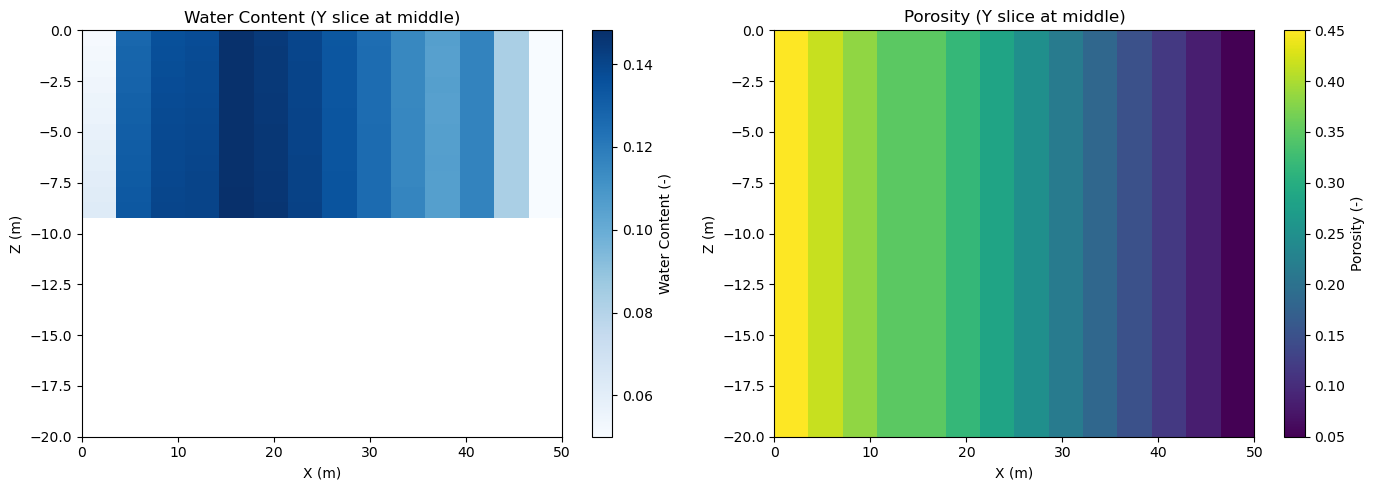

In [42]:
# Visualize a vertical slice of the synthetic data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Water content slice
slice_idx = water_content_3d.shape[2] // 2
im1 = axes[0].imshow(
    water_content_3d[:, :, slice_idx].T,
    extent=[0, domain_length, -domain_depth, 0],
    aspect='auto',
    cmap='Blues',
    origin='lower'
)
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Z (m)')
axes[0].set_title(f'Water Content (Y slice at middle)')
plt.colorbar(im1, ax=axes[0], label='Water Content (-)')

# Porosity slice
im2 = axes[1].imshow(
    porosity_3d[:, :, slice_idx].T,
    extent=[0, domain_length, -domain_depth, 0],
    aspect='auto',
    cmap='viridis',
    origin='lower'
)
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Z (m)')
axes[1].set_title(f'Porosity (Y slice at middle)')
plt.colorbar(im2, ax=axes[1], label='Porosity (-)')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'hydro_data_slices.png'), dpi=150)
plt.show()

## Step 4: Interpolate Hydrological Properties to 3D Mesh

Interpolate the MODFLOW data to mesh cell centers. Since our mesh follows
topography, we need to account for the local surface elevation when
determining the depth of each mesh cell.

In [43]:
from scipy.interpolate import RegularGridInterpolator

# Get mesh cell centers
cell_centers = np.array(mesh.cellCenters())
print(f"Number of mesh cells: {len(cell_centers)}")
print(f"Cell center bounds:")
print(f"  X: [{cell_centers[:,0].min():.2f}, {cell_centers[:,0].max():.2f}]")
print(f"  Y: [{cell_centers[:,1].min():.2f}, {cell_centers[:,1].max():.2f}]")
print(f"  Z: [{cell_centers[:,2].min():.2f}, {cell_centers[:,2].max():.2f}]")

# Calculate depth below local surface for each cell
cell_depths = np.zeros(len(cell_centers))
for i, (x, y, z) in enumerate(cell_centers):
    surface_z = topography_function(x, y)
    cell_depths[i] = surface_z - z  # Positive depth below surface

print(f"\nCell depths range: {cell_depths.min():.2f} to {cell_depths.max():.2f} m")

Number of mesh cells: 34650
Cell center bounds:
  X: [-24.44, 74.40]
  Y: [-15.56, 45.56]
  Z: [66.73, 101.87]

Cell depths range: 0.87 to 24.13 m


In [44]:
# Create grid coordinates for interpolation
# Using depth-relative coordinates (depth below local surface)
nlay, nrow, ncol = water_content_3d.shape

if USE_REAL_DATA:
    # For real MODFLOW data with 1m grid spacing
    # Adjust coordinates to match cropped region
    x_min = electrode_positions['x'].min()
    x_max = electrode_positions['x'].max()
    y_min = electrode_positions['y'].min()
    y_max = electrode_positions['y'].max()
    
    # Grid spacing (assuming 1m)
    dx = (x_max - x_min) / (ncol - 1) if ncol > 1 else 1.0
    dy = (y_max - y_min) / (nrow - 1) if nrow > 1 else 1.0
    
    # Assume depth is domain_depth spread across nlay layers
    dz = domain_depth / nlay
    
    # Cell center coordinates
    x_coords = np.linspace(x_min, x_max, ncol)
    y_coords = np.linspace(y_min, y_max, nrow)
    depth_coords = np.linspace(dz/2, domain_depth - dz/2, nlay)  # Positive depth
else:
    # For synthetic data
    dx = domain_length / ncol
    dy = domain_width / nrow
    dz = domain_depth / nlay
    
    x_coords = np.linspace(dx/2, domain_length - dx/2, ncol)
    y_coords = np.linspace(dy/2, domain_width - dy/2, nrow)
    depth_coords = np.linspace(dz/2, domain_depth - dz/2, nlay)

print(f"Grid coordinates for interpolation:")
print(f"  X: {x_coords.min():.2f} to {x_coords.max():.2f} ({len(x_coords)} points)")
print(f"  Y: {y_coords.min():.2f} to {y_coords.max():.2f} ({len(y_coords)} points)")
print(f"  Depth: {depth_coords.min():.2f} to {depth_coords.max():.2f} ({len(depth_coords)} points)")

Grid coordinates for interpolation:
  X: 2.50 to 47.50 (46 points)
  Y: 2.50 to 27.50 (26 points)
  Depth: 0.71 to 19.29 (14 points)


In [46]:
# Create interpolators for water content and porosity
# Handle NaN values in MODFLOW data (inactive cells)
wc_data = water_content_3d.copy()
por_data = porosity_3d.copy()

# Replace NaN values with reasonable defaults
default_wc = 0.15
default_por = 0.30
nan_count_wc = np.isnan(wc_data).sum()
nan_count_por = np.isnan(por_data).sum()

print(f"NaN values in water content: {nan_count_wc} ({100*nan_count_wc/wc_data.size:.1f}%)")
print(f"NaN values in porosity: {nan_count_por} ({100*nan_count_por/por_data.size:.1f}%)")

# Fill NaN with defaults
wc_data = np.nan_to_num(wc_data, nan=default_wc)
por_data = np.nan_to_num(por_data, nan=default_por)

# Reshape data: original is (nlay, nrow, ncol), need (ncol, nrow, nlay) for (x, y, depth)
wc_transposed = np.transpose(wc_data, (2, 1, 0))  # (ncol, nrow, nlay)
por_transposed = np.transpose(por_data, (2, 1, 0))

print(f"Transposed shapes: WC {wc_transposed.shape}, Por {por_transposed.shape}")

wc_interpolator = RegularGridInterpolator(
    (x_coords, y_coords, depth_coords),
    wc_transposed,
    method='linear',
    bounds_error=False,
    fill_value=default_wc
)

por_interpolator = RegularGridInterpolator(
    (x_coords, y_coords, depth_coords),
    por_transposed,
    method='linear',
    bounds_error=False,
    fill_value=default_por
)

# Interpolate to mesh cell centers using (x, y, depth) coordinates
# Create interpolation points: (x, y, depth_below_surface)
interp_points = np.column_stack([
    cell_centers[:, 0],  # x
    cell_centers[:, 1],  # y
    cell_depths          # depth below local surface
])

wc_mesh = wc_interpolator(interp_points)
porosity_mesh = por_interpolator(interp_points)

# Calculate saturation (ensure no division by zero)
porosity_mesh = np.maximum(porosity_mesh, 0.05)  # Minimum porosity
saturation_mesh = np.clip(wc_mesh / porosity_mesh, 0.0, 1.0)

print(f"\nInterpolated values on mesh:")
print(f"  Water content: min={wc_mesh.min():.3f}, max={wc_mesh.max():.3f}")
print(f"  Porosity: min={porosity_mesh.min():.3f}, max={porosity_mesh.max():.3f}")
print(f"  Saturation: min={saturation_mesh.min():.3f}, max={saturation_mesh.max():.3f}")

NaN values in water content: 9030 (53.9%)
NaN values in porosity: 0 (0.0%)
Transposed shapes: WC (46, 26, 14), Por (46, 26, 14)

Interpolated values on mesh:
  Water content: min=0.059, max=0.150
  Porosity: min=0.068, max=0.444
  Saturation: min=0.133, max=1.000


## Step 5: Convert Water Content to Resistivity

Use the Waxman-Smits petrophysical model to convert saturation and
porosity to electrical resistivity.

In [47]:
# Petrophysical parameters (Waxman-Smits model)
sigma_w = 0.05  # Conductivity of pore water (S/m) - ~20 Ohm-m
m = 1.5         # Cementation exponent
n = 2.0         # Saturation exponent
sigma_s = 0.001 # Surface conductivity (S/m)

# Convert to resistivity using Waxman-Smits model
# res = 1 / (sigma_w * porosity^m * saturation^n + sigma_s)
resistivity_mesh = WS_Model(
    saturation_mesh,
    porosity_mesh,
    sigma_w,
    m,
    n,
    sigma_s
)

# Ensure valid resistivity values
resistivity_mesh = np.clip(resistivity_mesh, 10, 10000)

print(f"Resistivity on mesh: min={resistivity_mesh.min():.1f} Ohm-m, max={resistivity_mesh.max():.1f} Ohm-m")

Resistivity on mesh: min=349.7 Ohm-m, max=3340.5 Ohm-m


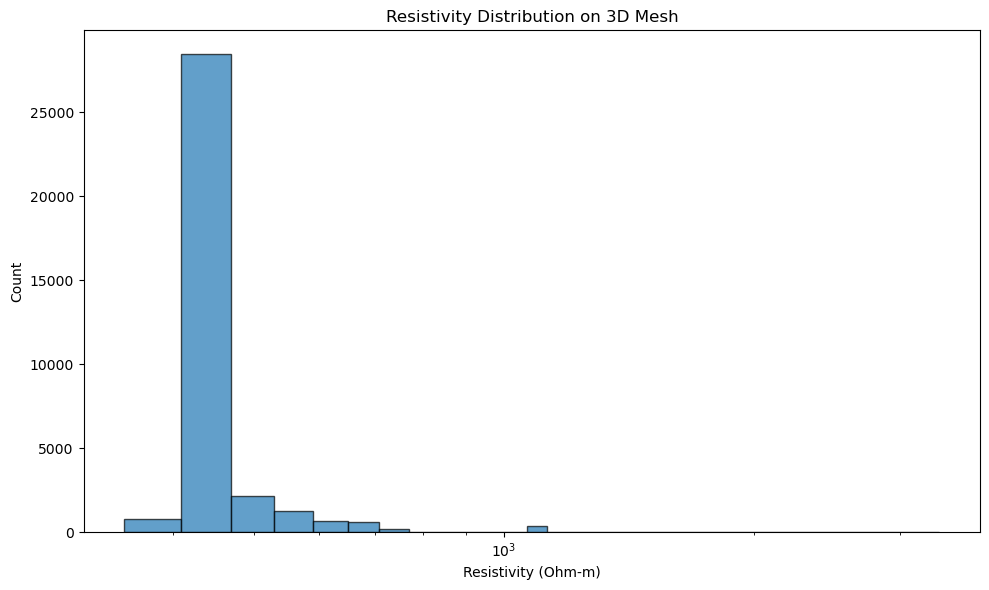

In [48]:
# Visualize resistivity distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(resistivity_mesh, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Resistivity (Ohm-m)')
ax.set_ylabel('Count')
ax.set_title('Resistivity Distribution on 3D Mesh')
ax.set_xscale('log')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'resistivity_histogram.png'), dpi=150)
plt.show()

## Step 6: Perform 3D ERT Forward Modeling

In [49]:
# Create forward modeling operator
fop = ert.ERTModelling()
fop.setData(data)
fop.setMesh(mesh)

print(f"Forward operator configured")
print(f"  Data points: {data.size()}")
print(f"  Model cells: {mesh.cellCount()}")

13/01/26 - 16:28:46 - pyGIMLi - INFO - Found 3 regions.
13/01/26 - 16:28:46 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


Forward operator configured
  Data points: 1653
  Model cells: 34650


In [50]:
# Perform forward modeling
print("Running 3D ERT forward modeling...")
response = fop.response(resistivity_mesh)
print(f"Forward modeling complete!")
print(f"Response: min={np.min(response):.2f}, max={np.max(response):.2f} Ohm-m")

13/01/26 - 16:28:49 - pyGIMLi - INFO - Creating forward mesh from region infos.
13/01/26 - 16:28:51 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.


Running 3D ERT forward modeling...


13/01/26 - 16:28:55 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 142975 Cells: 277200 Boundaries: 354108


Forward modeling complete!
Response: min=8.26, max=26726.06 Ohm-m


In [51]:
# Add noise to create synthetic "measured" data
np.random.seed(42)
noise_level = 0.03  # 3% relative error
response_noisy = response * (1.0 + noise_level * np.random.randn(len(response)))

# Store in data container
data['rhoa'] = response_noisy
data['err'] = np.abs(noise_level * response_noisy)  # Absolute error

# Estimate error using ERTManager
mgr = ert.ERTManager(data)
data['err'] = mgr.estimateError(data, relativeError=noise_level, absoluteUError=1e-4)

print(f"Synthetic data with {noise_level*100:.0f}% noise added")

Synthetic data with 3% noise added


In [52]:
# Save synthetic data
data.save(os.path.join(output_dir, 'synthetic_3d_data.dat'))
print(f"Synthetic data saved to {output_dir}/synthetic_3d_data.dat")

Synthetic data saved to results/3d_ert_workflow/synthetic_3d_data.dat


## Step 7: Visualize Results

13/01/26 - 16:33:27 - pyGIMLi - INFO - found 57 x values
13/01/26 - 16:33:27 - pyGIMLi - INFO - found 57 y values
13/01/26 - 16:33:27 - pyGIMLi - INFO - x vector length: 1653
13/01/26 - 16:33:27 - pyGIMLi - INFO - y vector length: 1653
13/01/26 - 16:33:27 - pyGIMLi - INFO - v vector length: 1653


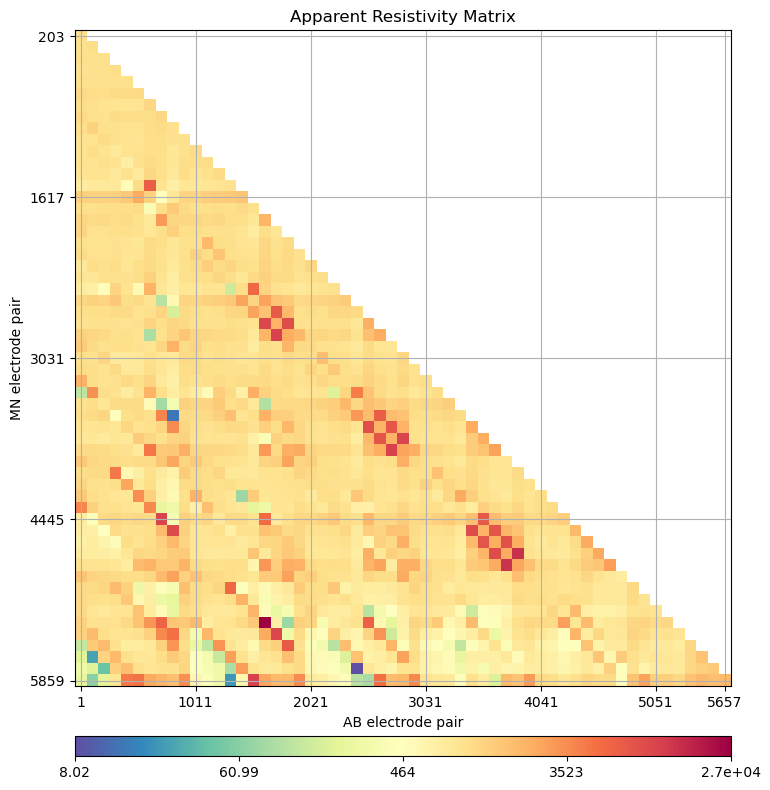

In [53]:
# Visualize apparent resistivity data
from pygimli.viewer.mpl import showDataContainerAsMatrix

# Create pseudo-indices for visualization
ab = data['a'] * 100 + data['b']
mn = data['m'] * 100 + data['n']

fig, ax = plt.subplots(figsize=(10, 8))
ax, cb = showDataContainerAsMatrix(data, ab, mn, 'rhoa', ax=ax, cMap='Spectral_r')
ax.set_xlabel('AB electrode pair')
ax.set_ylabel('MN electrode pair')
ax.set_title('Apparent Resistivity Matrix')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'rhoa_matrix.png'), dpi=150)
plt.show()

c:\Users\hchen117\.conda\envs\pg\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


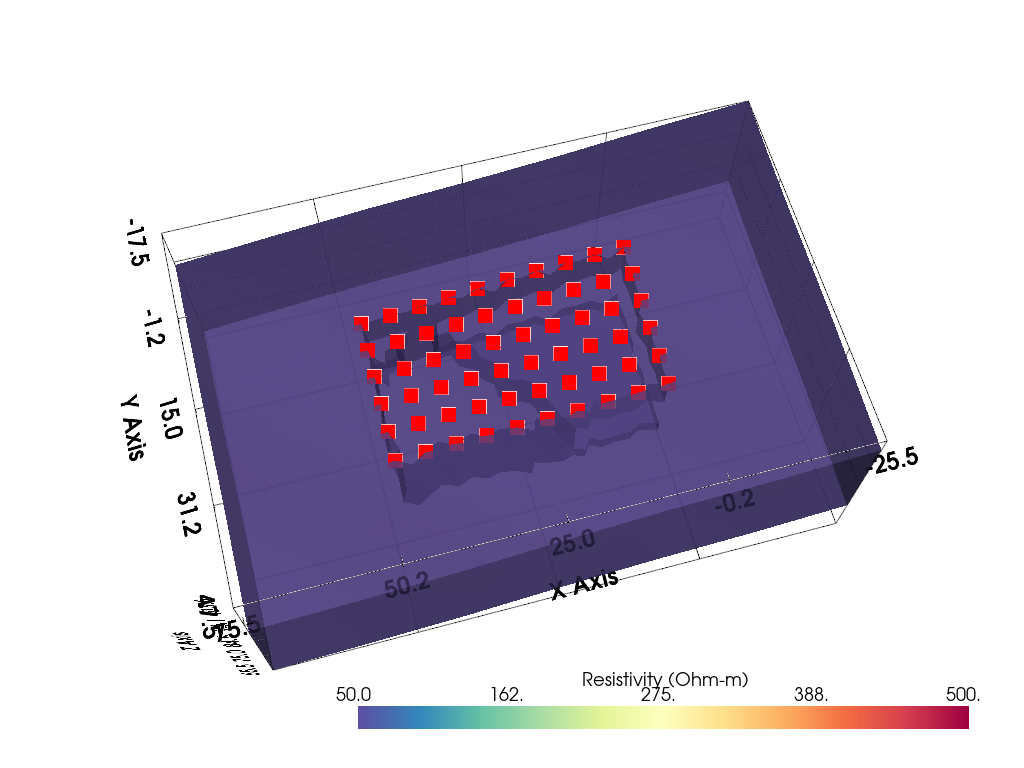

In [54]:
# 3D visualization with PyVista (if available)
if PYVISTA_AVAILABLE:
    # Add resistivity to mesh for visualization
    mesh['resistivity'] = resistivity_mesh
    
    # Create plotter
    pl = pv.Plotter()
    
    # Convert PyGIMLi mesh to PyVista
    mesh.exportVTK(os.path.join(output_dir, 'mesh_with_res.vtk'))
    pv_mesh = pv.read(os.path.join(output_dir, 'mesh_with_res.vtk'))
    
    # Add mesh with threshold to see inside
    pl.add_mesh(
        pv_mesh.threshold([50, 500], scalars='resistivity'),
        cmap='Spectral_r',
        clim=[50, 500],
        opacity=0.8,
        scalar_bar_args={'title': 'Resistivity (Ohm-m)'}
    )
    
    # Add electrode positions
    electrode_points = electrode_positions[['x', 'y', 'z']].values
    pl.add_points(electrode_points, color='red', point_size=15)
    
    # Set camera and show
    pl.camera_position = 'iso'
    pl.camera.azimuth = 30
    pl.camera.elevation = 30
    pl.show_bounds(grid='back')
    
    # Save screenshot
    pl.screenshot(os.path.join(output_dir, '3d_resistivity_model.png'))
    pl.show()
else:
    print("PyVista not available. Skipping 3D visualization.")
    print("Install with: pip install pyvista")

c:\Users\hchen117\.conda\envs\pg\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


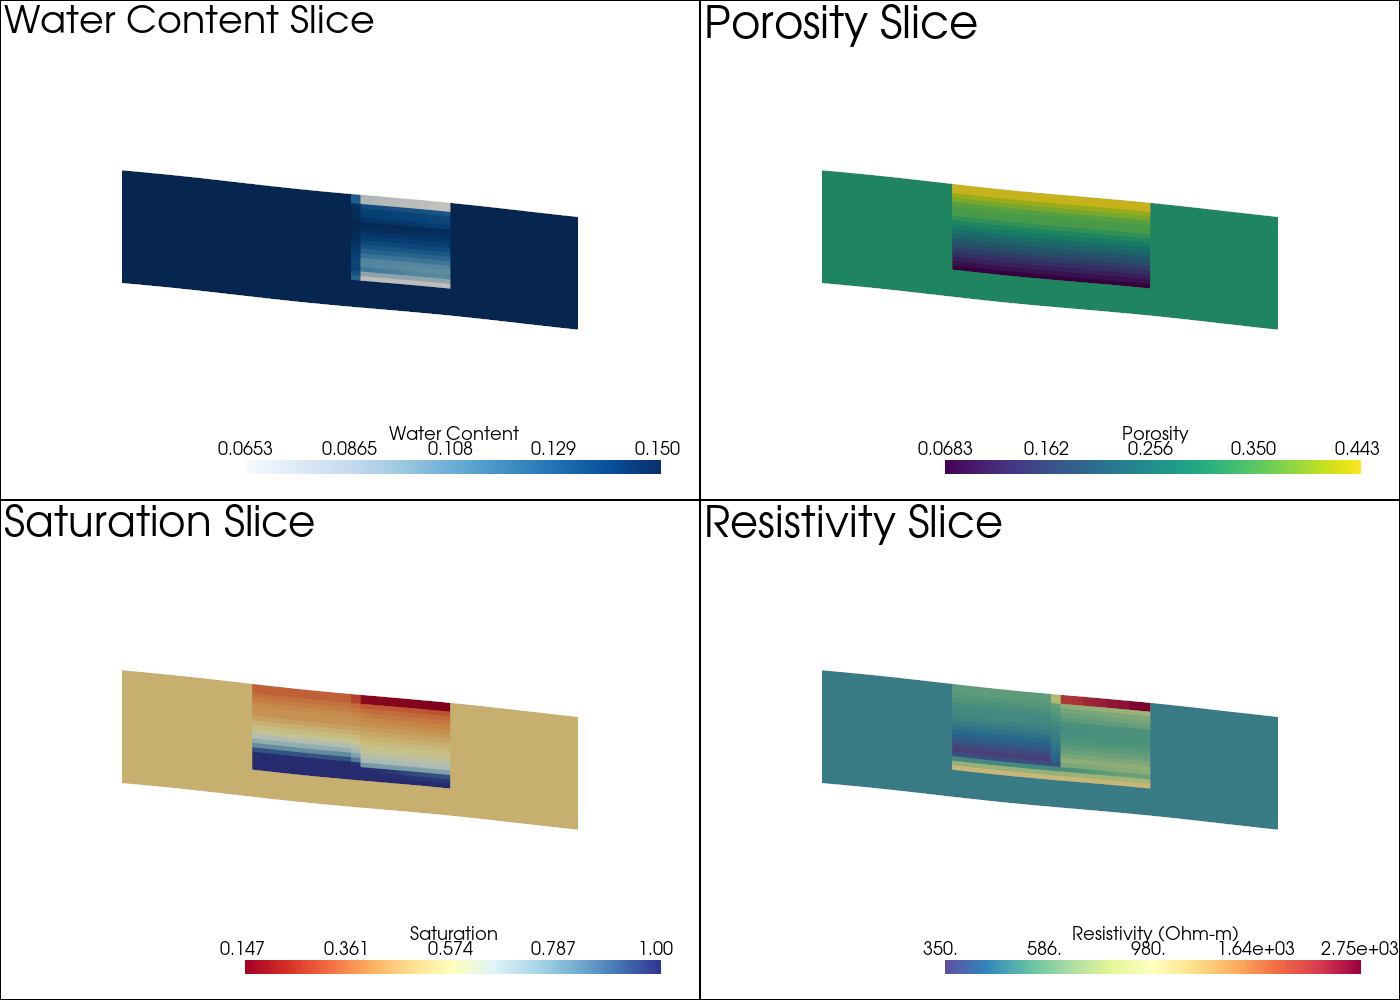

In [56]:
# Create 2D slices for visualization
if PYVISTA_AVAILABLE:
    # Export mesh with data
    mesh['water_content'] = wc_mesh
    mesh['porosity'] = porosity_mesh
    mesh['saturation'] = saturation_mesh
    mesh['resistivity'] = resistivity_mesh
    
    mesh.exportVTK(os.path.join(output_dir, 'mesh_with_all_data.vtk'))
    pv_mesh = pv.read(os.path.join(output_dir, 'mesh_with_all_data.vtk'))
    
    # Create multi-view visualization
    pl = pv.Plotter(shape=(2, 2), window_size=(1400, 1000))
    
    # Get mesh center for slicing
    mesh_center = pv_mesh.center
    
    # Slice at different locations
    slice_y = pv_mesh.slice(normal='y', origin=mesh_center)
    
    # Plot 1: Water content
    pl.subplot(0, 0)
    pl.add_mesh(slice_y, scalars='water_content', cmap='Blues',
                scalar_bar_args={'title': 'Water Content'})
    pl.add_text('Water Content Slice', position='upper_left')
    pl.view_xz()
    
    # Plot 2: Porosity
    pl.subplot(0, 1)
    pl.add_mesh(slice_y.copy(), scalars='porosity', cmap='viridis',
                scalar_bar_args={'title': 'Porosity'})
    pl.add_text('Porosity Slice', position='upper_left')
    pl.view_xz()
    
    # Plot 3: Saturation  
    pl.subplot(1, 0)
    pl.add_mesh(slice_y.copy(), scalars='saturation', cmap='RdYlBu',
                scalar_bar_args={'title': 'Saturation'})
    pl.add_text('Saturation Slice', position='upper_left')
    pl.view_xz()
    
    # Plot 4: Resistivity
    pl.subplot(1, 1)
    pl.add_mesh(slice_y.copy(), scalars='resistivity', cmap='Spectral_r',
                log_scale=True, scalar_bar_args={'title': 'Resistivity (Ohm-m)'})
    pl.add_text('Resistivity Slice', position='upper_left')
    pl.view_xz()
    
    # Save and show
    pl.screenshot(os.path.join(output_dir, '2d_slices.png'))
    pl.show()
else:
    print("PyVista not available for slice visualization.")

## Step 8: Alternative Mesh Creation Methods

The `mesh_3d.py` module supports multiple mesh creation approaches:

### Option A: Prism Mesh (used above)
- Created with `create_3d_mesh_with_topography(use_prism_mesh=True)`
- Efficient for layered structures
- Triangular prisms extruded from 2D mesh

### Option B: Tetrahedral Mesh
- Created with `create_3d_mesh_with_topography(use_prism_mesh=False)`
- Uses PyGIMLi's `createParaMeshPLC3D`
- Better for complex 3D structures

### Option C: Manual Prism Mesh
- Use `create_prism_mesh_from_2d(mesh2d, z_vector)` for custom control

Below we show the manual approach for comparison:

In [57]:
# Alternative: Manual 2D mesh creation for prism extrusion
# This gives you more control over the 2D base mesh

# Get unique x-y positions from electrodes
xy_positions = electrode_positions[['x', 'y']].drop_duplicates().values

# Create 2D surface mesh using mesh_3d.py
mesh2d = mesh_creator.create_surface_mesh_with_topography(
    electrode_positions=electrode_positions,
    boundary_extension=1.4,
    area=2.0,
    quality=34.3
)

# Add boundary region
boundary_size = 5
mesh2d_with_bnd = mt.appendTriangleBoundary(
    mesh2d, boundary=boundary_size, isSubSurface=False, marker=1
)

print(f"2D base mesh: {mesh2d_with_bnd}")

2D base mesh: Mesh: Nodes: 2165 Cells: 4304 Boundaries: 6468


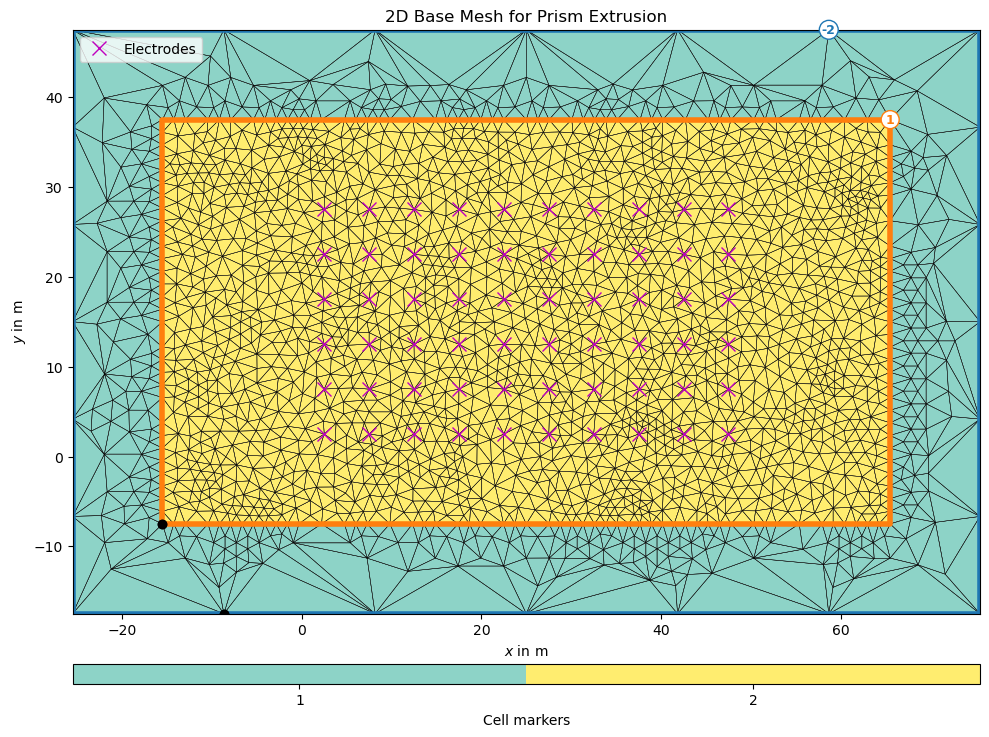

In [58]:
# Visualize 2D mesh
fig, ax = plt.subplots(figsize=(10, 8))
pg.show(mesh2d_with_bnd, markers=True, showMesh=True, ax=ax)
ax.plot(*xy_positions.T, 'mx', markersize=10, label='Electrodes')
ax.legend()
ax.set_title('2D Base Mesh for Prism Extrusion')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '2d_base_mesh.png'), dpi=150)
plt.show()

In [59]:
# Create z-discretization vector
dz_coarse = 2.0  # Coarser spacing for top/bottom
dz_fine = 0.5    # Finer spacing in middle

z_top = np.arange(0, 2, dz_coarse)
z_mid = np.arange(z_top[-1], domain_depth - 2, dz_fine)
z_bot = np.arange(z_mid[-1], domain_depth + boundary_size + 0.1, dz_coarse)

z_vec = -np.concatenate([z_top, z_mid[1:], z_bot[1:]])
print(f"Z-vector: {len(z_vec)} levels from {z_vec.min():.1f} to {z_vec.max():.1f}")

Z-vector: 39 levels from -23.5 to -0.0


In [60]:
# Create 3D prism mesh using mesh_3d.py
mesh3d_prism = mesh_creator.create_prism_mesh_from_2d(
    mesh2d=mesh2d_with_bnd,
    z_vector=z_vec,
    surface_marker=1,
    subsurface_marker=2
)

print(f"3D prism mesh: {mesh3d_prism}")

# Set markers based on depth
depth_top = 2.0  # Top region
depth_bot = domain_depth - 2.0  # Bottom region

for c in mesh3d_prism.cells():
    cd = -c.center().z()  # Center depth (positive)
    if cd < depth_top or cd > depth_bot:
        c.setMarker(1)  # Boundary region

# Save prism mesh
mesh3d_prism.save(os.path.join(output_dir, 'mesh_3d_prism.bms'))
mesh3d_prism.exportVTK(os.path.join(output_dir, 'mesh_3d_prism.vtk'))
print(f"Prism mesh saved to {output_dir}")

3D prism mesh: Mesh: Nodes: 84435 Cells: 163552 Boundaries: 15638
Prism mesh saved to results/3d_ert_workflow


## Summary

This notebook demonstrated:

1. **mesh_3d.py Module Tutorial**: Learned how to use the `Mesh3DCreator` class
2. **Electrode Layout with Topography**: Created surface electrodes following terrain
3. **3D Mesh with Topography**: Used `create_3d_mesh_with_topography()` for realistic terrain
4. **Data Integration**: Interpolated MODFLOW outputs using depth-relative coordinates
5. **Petrophysics**: Converted water content/saturation to resistivity using Waxman-Smits
6. **Forward Modeling**: Computed synthetic 3D ERT response
7. **Visualization**: Created 3D visualizations using PyVista

---

## mesh_3d.py Quick Reference

### Mesh3DCreator Methods

| Method | Description |
|--------|-------------|
| `create_surface_electrode_array(nx, ny, dx, dy, ...)` | Regular grid of surface electrodes |
| `create_borehole_electrode_array(x, y, z_positions)` | Single borehole electrodes |
| `create_crosshole_electrode_array(borehole_positions, z_positions)` | Multiple boreholes |
| `apply_topography_to_electrodes(electrodes, topography_func)` | Set electrode z from topography |
| `create_3d_mesh_with_topography(electrodes, topography_func, ...)` | **Main method for terrain-following mesh** |
| `create_box_mesh(length, width, height, electrodes)` | Simple flat box mesh |
| `create_prism_mesh_from_2d(mesh2d, z_vector)` | Extrude 2D mesh to prisms |
| `visualize_mesh(mesh, electrode_positions)` | 3D visualization with PyVista |

### Helper Functions

| Function | Description |
|----------|-------------|
| `create_3d_ert_data_container(electrodes, scheme, dim)` | Create ERT data with 3D geometric factors |
| `interpolate_modflow_to_3d_mesh(mesh, data, grid)` | Interpolate MODFLOW data to mesh |
| `export_electrodes_to_csv(electrodes, path)` | Save electrodes to CSV |

### Next Steps

- Perform 3D ERT inversion using `ert.ERTManager`
- Compare inverted model with true model
- Analyze resolution and sensitivity
- Time-lapse monitoring applications

In [61]:
print("=" * 60)
print("3D ERT forward modeling workflow complete!")
print("=" * 60)
print(f"\nOutput files saved to: {output_dir}")
print("  - mesh_3d.bms/vtk: Tetrahedral mesh with topography")
print("  - mesh_3d_prism.bms/vtk: Prism mesh")
print("  - synthetic_3d_data.dat: Synthetic ERT data")
print("  - Various visualization plots")
print("\n" + "=" * 60)
print("Key mesh_3d.py functions used:")
print("=" * 60)
print("  - Mesh3DCreator()                        : Initialize mesh creator")
print("  - create_surface_electrode_array()       : Create electrode grid")
print("  - apply_topography_to_electrodes()       : Apply surface elevation")
print("  - create_3d_mesh_with_topography()       : Create terrain-following mesh")
print("  - create_3d_ert_data_container()         : Create ERT data with 3D k-factors")

3D ERT forward modeling workflow complete!

Output files saved to: results/3d_ert_workflow
  - mesh_3d.bms/vtk: Tetrahedral mesh with topography
  - mesh_3d_prism.bms/vtk: Prism mesh
  - synthetic_3d_data.dat: Synthetic ERT data
  - Various visualization plots

Key mesh_3d.py functions used:
  - Mesh3DCreator()                        : Initialize mesh creator
  - create_surface_electrode_array()       : Create electrode grid
  - apply_topography_to_electrodes()       : Apply surface elevation
  - create_3d_mesh_with_topography()       : Create terrain-following mesh
  - create_3d_ert_data_container()         : Create ERT data with 3D k-factors
